In [17]:
from attention_predict.benchmark import evaluate
from attention_predict.unet import UNet
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [51]:
device = 'cuda:2'

ds_name = 'AVA_MC_SMDV'
num_neurons = 3
depth = 5
base = '/home/alicia/notebook/alicia/worm-dynamics'

in_channels = np.load(f'{base}/data/{ds_name}.npy').shape[1]
out_channels = in_channels
num_inputs = in_channels
model = UNet(depth, in_channels, out_channels, unet_dim=1).to(device)

exp = 'exp_2024100501' # AVA | MC | SMDV | velocity | pumping | head angle
control_exp = 'exp_2024101100_control'
ckpt_num = 30

control_ckpt_dir = f'/home/alicia/store1/alicia/attention_predict/{control_exp}/checkpoints'
control_model_ckpt_path = f'{control_ckpt_dir}/model_ckpt{ckpt_num}.pt'

ckpt_dir = f'/home/alicia/store1/alicia/attention_predict/{exp}/checkpoints'
model_ckpt_path = f'{ckpt_dir}/model_ckpt{ckpt_num}.pt'

# 0: AVA | 1: MC | 2: SMDV | 3: velocity | 4: pumping | 5: head angle
mask_indices = [1, 5]
data_path = f'{base}/data/{ds_name}_eval.npy'
dataset_path = f'{base}/data/{ds_name}_eval_ds.npy'

mse_per_dataset, sample_metainfo = evaluate(
    model,
    model_ckpt_path,
    mask_indices,
    data_path,
    dataset_path,
    num_inputs,
    num_neurons,
    device=device)

control_mse_per_dataset, control_metainfo = evaluate(
    model,
    control_model_ckpt_path,
    mask_indices,
    data_path,
    dataset_path,
    num_inputs,
    num_neurons,
    device=device)

dataset length: 34829
dataset length: 34829


In [52]:
eval_datasets = ['2022-06-14-13',
 '2022-06-28-07',
 '2023-01-09-15',
 '2023-01-16-08',
 '2023-01-18-01',
 '2023-01-23-01',
 '2023-07-01-01',
 '2023-08-18-18',
 '2023-10-15-18',
 '2024-05-02-04',
 '2024-05-02-13']

average_mse = {}

for ds, mse_dict in mse_per_dataset.items():
    
    if ds not in eval_datasets:
        continue
    
    average_mse[ds] = {}
    for col in mse_dict.keys():
        average_mse[ds][col] = np.mean(mse_dict[col])

In [53]:
control_average_mse = {}

for ds, mse_dict in control_mse_per_dataset.items():
    
    if ds not in eval_datasets:
        continue
        
    control_average_mse[ds] = {}
    for col in mse_dict.keys():
        control_average_mse[ds][col] = np.mean(mse_dict[col])

In [54]:
# Melt the DataFrame for plotting
df_control = pd.DataFrame(control_average_mse).T.reset_index().melt(id_vars='index', var_name='Column', value_name='Value')
df_control['Type'] = 'Control'  # Add a column for type

df_experiment = pd.DataFrame(average_mse).T.reset_index().melt(id_vars='index', var_name='Column', value_name='Value')
df_experiment['Type'] = 'Experiment'  # Add a column for type

# Combine the two melted DataFrames
df_combined = pd.concat([df_control, df_experiment], ignore_index=True)
df_combined.columns = ['Dataset', 'Column', 'Value', 'Type']

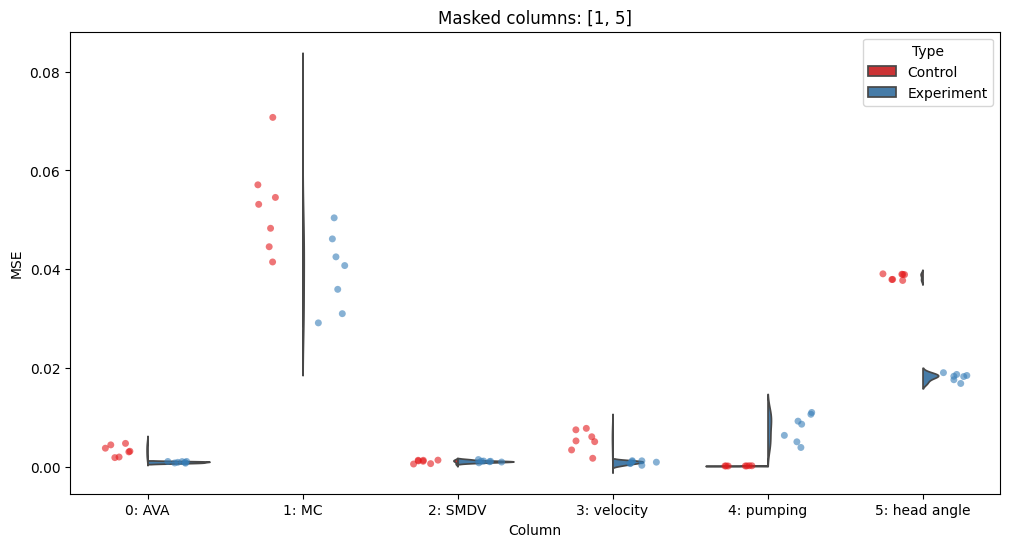

In [55]:

palette = 'Set1'
column_labels = ['0: AVA', '1: MC', '2: SMDV', '3: velocity', '4: pumping', '5: head angle']

plt.figure(figsize=(12, 6))

# Violin plot with color palette
sns.violinplot(x='Column', y='Value', hue='Type', data=df_combined, split=True, inner=None, palette=palette)

# Overlay scatter points, matching the hue colors to the violin plot palette
sns.stripplot(x='Column', y='Value', hue='Type', data=df_combined, dodge=True, jitter=0.2, palette=palette, marker='o', alpha=0.6)

plt.xticks(ticks=range(len(column_labels)), labels=column_labels)

# Adjust the legend to avoid duplication
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:2], labels[:2], title='Type')
plt.xlabel('Column')
plt.ylabel('MSE')
plt.title(f'Masked columns: {mask_indices}')
plt.show()

In [56]:
df_combined[df_combined['Column'] == 3]

,Dataset,Column,Value,Type
21,2023-01-09-15,3,0.005248,Control
22,2024-05-02-13,3,0.007499,Control
23,2023-01-16-08,3,0.007793,Control
24,2023-01-18-01,3,0.006090,Control
25,2022-06-28-07,3,0.003423,Control
26,2023-07-01-01,3,0.005100,Control
27,2024-05-02-04,3,0.001737,Control
63,2023-01-09-15,3,0.001057,Experiment
64,2024-05-02-13,3,0.000657,Experiment
65,2023-01-16-08,3,0.000948,Experiment
